In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [13]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000002311E516B00>, default_metadata=(), model_kwargs={})

In [14]:
#Pydantic LLM Schema
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not_funny"] = Field(description="Is the response funny or not?")

llm_with_schema = llm.with_structured_output(llm_schema)

# llm_with_schema.invoke("What is capital of France and what is population of France? ")

In [15]:
#Graph Schema
class graph_schema(TypedDict):
    topic:str
    joke:str
    funny_flag:str
    feedback:str
    max_iterations:int

In [16]:
def generate_joke(state:graph_schema) -> graph_schema:

    topic = state["topic"]

    if state["feedback"]:
        response = llm.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback'] }")
        pass
    else:
        response = llm.invoke(f"Generate a joke on the topic: {topic}")


    state["joke"] = response.content
    return state

In [17]:
def evaluate_node(state:graph_schema) -> graph_schema:
    joke = state["joke"]
    iteration = state["max_iterations"]

    prompt = ChatPromptTemplate.from_messages(
        [
            "system: You are a comedy critic. Your task is to evaluate the funniness of a joke and provide feedback for improvement.",
            "user: Here is the joke: {joke}. Please evaluate its funniness and provide feedback for improvement. Respond with 'funny' or 'not_funny' and provide specific feedback for improvement."
        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state["funny_flag"] = response.funny_flag
    state["feedback"] = response.feedback
    state["max_iterations"] = iteration + 1

    return state

In [18]:
#Conditional Edge Function
def check_iteration(state:graph_schema) -> str:

    iteration = state["max_iterations"]
    if iteration >= 5 and state["funny_flag"] == "not_funny":
        return "evaluate_node"
    else:
        return "end"    

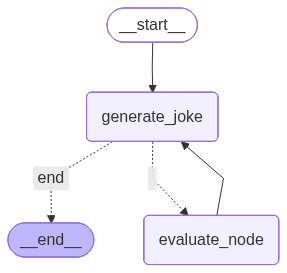

In [19]:
#Create State Graph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("generate_joke", generate_joke)
graph.add_node("evaluate_node", evaluate_node)
graph.add_edge(START, "generate_joke")
graph.add_conditional_edges("generate_joke",check_iteration,{evaluate_node: "evaluate_node", "end":END})
graph.add_edge("evaluate_node", "generate_joke")
graph.add_edge("evaluate_node", END)

evaluator_graph = graph.compile()

#Step 4 Compile the graph
from IPython.display import Image, display

Image(evaluator_graph.get_graph().draw_mermaid_png())


In [ ]:
evaluator_graph.invoke({
    "topic": "technology",
    "joke": "",
    "funny_flag": "",
    "feedback": "",
    "max_iterations": 0
})

{'topic': 'technology',
 'joke': [{'type': 'text',
   'text': "The inventor of the USB drive has died. At the funeral, the pallbearers lowered the coffin into the grave, but it didn't fit. \n\nThey had to pull it back out, flip it over, and lower it again. \n\nIt still didn't fit, so they pulled it back out, flipped it over *one more time*, and then it went in perfectly.",
   'extras': {'signature': 'EtQeCtEeAb4+9vvb5y93nHUu8R1BrmTXOopUlL73MgIVenWTEtZEVK2a14mKJgwQTTtY5hlLWa7pnieafS2oNT++Pwah9JYNexYtVoe3i9nT1kwa4XydsEOngT4QvhlSKZuzbSO2MszqyZoHCJLX/RR2/AptkJ9gMPAc594jVr9vbN2qGsCvzxmZYSfCL9P7IY2SDktNleCGf3GQOMG/WJOyx37RxGAJEP8RxcazomGmSaaarYkbQUBK/lZimsi5b9qeNkdVR/Ao4E/a/Xg2KpanRQyHE74Nk6ESj66Q7TrOlTjFDpuPAzRQ3i8Rqpamqk58lWzBfgoxKSV0sg3um63dDKTyCLI3R0DvCQ1HdMEMonUPaHGmUBofaGpTs6fUXJAxsPJWPL5nKtig4dOMQY8JxyoBkIhtrZn2pTj/ANo7ZijfTX2FK6yU7og0oIiYXDB7pYXtNn4Uq3GOhHqANTxVhYKQszgimS1jJ/CmBcH6f8X8SuLOYuNbXFicjxrd2ytsBgnhlg++DwEIWfQISQWecARuQqz3949nreA1v2jVOSm1dd6bnCEM2SY5yT9fxurNQ5Hu5yw8/VCeRFOM